# Evaluación multi-modelo — PM2Nbody

**Orquestador puro.** Toda la lógica de dispatch, métricas e I/O vive en `pm2nbody/eval_utils.py`.

Flujo:
1. Configura `RUNS`, `DATA_DIR`, `TEST_SIM_IDS` en la celda de usuario
2. `eu.verify_runs(RUNS)` valida que todos los checkpoints existen
3. Bucle de evaluación — secuencial y memory-safe
4. Visualizaciones estándar (P(k)/P_HR, r(k), MSE pos, slabs de densidad)
5. Export a CSV / JSON con `eu.save_results`

## 0 · Entorno

In [1]:
import sys, os
from pathlib import Path

# ── Raíz del repositorio ──────────────────────────────────────────────────────
# Busca setup.py / pyproject.toml ascendiendo desde cwd; fallback a cwd/../..
_here = Path.cwd()
REPO_ROOT = _here.parents[1]  # fallback: notebooks/ → pm2nbody/ → repo/
for _p in [_here, *_here.parents]:
    if (_p / "setup.py").exists() or (_p / "pyproject.toml").exists():
        REPO_ROOT = _p
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("REPO_ROOT:", REPO_ROOT)

# JAX
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.85")
import jax
jax.config.update("jax_enable_x64", False)
print("JAX devices:", jax.devices())

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

import pm2nbody.eval_utils as eu

REPO_ROOT: /cosmos_storage/home/diegovillalba/JaxPM


JAX devices: [CudaDevice(id=0)]


/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## 1 · Configuración de usuario

> **Edita sólo esta celda.** El resto del notebook es genérico.

### Formato de `RUNS`
```python
RUNS = {
    # nombre de display    : None → baseline LR sin corrección
    "LR (baseline)"        : None,

    # Path → usa best*.pkl del directorio
    "cnn_wst v1"           : MODELS_DIR / "mi-run-cnn-wst",

    # dict  → checkpoint concreto (step o "best")
    "transformer step 100" : {"dir": MODELS_DIR / "mi-run-pt", "checkpoint": "100"},
}
```

In [5]:
# ── Directorios ───────────────────────────────────────────────────────────────
DATA_DIR    = REPO_ROOT / "data/matched_128_256_L256.0_S50_Np128"          # donde están pos_m128_s0.npy etc.
MODELS_DIR  = REPO_ROOT / "models"        # raíz de las corridas entrenadas
RESULTS_DIR = REPO_ROOT / "eval_results"  # salida de save_results()

# ── Simulaciones de test ──────────────────────────────────────────────────────
TEST_SIM_IDS = [0]      # lista de IDs a evaluar, e.g. [0, 1, 2]

# ── Snapshots a evaluar ───────────────────────────────────────────────────────
# Índices sobre el array de scale_factors (0..49 para 50 snapshots)
SNAP_EVAL = list(range(0, 50, 5))   # cada 5 snapshots → 10 puntos

# ── Resolución de la simulación ───────────────────────────────────────────────
MESH_LR   = 128
MESH_HR   = 256
BOX_SIZE  = 256.0   # Mpc/h

# ── Cosmología ────────────────────────────────────────────────────────────────
import jax_cosmo as jc
COSMOLOGY = jc.Planck15()

# ── Registro de corridas ──────────────────────────────────────────────────────
RUNS = {
    "LR (baseline)"        : None,
    "Best CNN"         : MODELS_DIR / "electric-dream-78",
    "patched_transformer": MODELS_DIR / "peachy-shape-91",
}

## 2 · Verificación de corridas

In [3]:
eu.verify_runs(RUNS)

Corrida                                  Estado         type                      Checkpoint
─────────────────────────────────────────────────────────────────────────────────────────────────────────
LR (baseline)                            ✓ baseline     —                         —
Best CNN                                 ✓ ok           cnn                       best_0.000_weights.pkl
patched_transformer                      ✓ ok           patched_transformer       best_0.000_weights_100.pkl
─────────────────────────────────────────────────────────────────────────────────────────────────────────


## 3 · Bucle de evaluación

Cada corrida se evalúa secuencialmente para mantener el uso de memoria bajo control.
Los arrays JAX se descargan a CPU (`jax.device_get`) y se borra el caché de compilación
antes de cargar el siguiente modelo.

In [6]:
# ── Cargar escala de factores (compartida entre sims) ─────────────────────────
import numpy as _np
avals_cpu = _np.load(DATA_DIR / "scale_factors.npy").astype("float32")
print(f"scale_factors: {avals_cpu[[0, -1]]} ({len(avals_cpu)} pasos)")

# ── Almacén de resultados ─────────────────────────────────────────────────────
# results[run_name][sim_id] = compute_sim_metrics(...)
results = {name: {} for name in RUNS}
k_bins  = None   # se llena con el primer compute_sim_metrics

for run_name, run_entry in RUNS.items():
    print(f"\n{'='*60}")
    print(f"Corrida: {run_name}")

    # Cargar modelo (None → baseline LR)
    if run_entry is None:
        run_info = None
        print("  [baseline — sin modelo]")
    else:
        run_info = eu.load_run(run_entry)
        print(f"  type={run_info['type']}  pkl={run_info['pkl_file'].name}")

    for sim_id in TEST_SIM_IDS:
        print(f"  sim {sim_id} …", end=" ", flush=True)

        # ── Datos ──────────────────────────────────────────────────────────────
        pos_lr, vel_lr, pos_hr, vel_hr, avals = eu.load_sim(
            DATA_DIR, sim_id, MESH_LR, MESH_HR, BOX_SIZE
        )

        # ── Integración ODE ────────────────────────────────────────────────────
        if run_info is None:
            # LR baseline: la ODE sin corrección
            pos_pm, _ = eu.run_ode(
                pos_lr[0], vel_lr[0], avals,
                model=None, params=None,
                ode_type=None, mesh_lr=MESH_LR, cosmology=COSMOLOGY,
            )
        else:
            pos_pm, _ = eu.run_ode(
                pos_lr[0], vel_lr[0], avals,
                model=run_info["model"],
                params=run_info["params"],
                ode_type=run_info["ode_type"],
                mesh_lr=MESH_LR,
                cosmology=COSMOLOGY,
            )

        # Descargar a CPU antes de calcular métricas
        pos_pm_cpu = jax.device_get(pos_pm)
        pos_hr_cpu = jax.device_get(pos_hr)
        del pos_pm, pos_lr, vel_lr, pos_hr, vel_hr, avals

        # ── Métricas ───────────────────────────────────────────────────────────
        metrics = eu.compute_sim_metrics(
            pos_pm_cpu, pos_hr_cpu,
            snap_indices=SNAP_EVAL,
            avals_cpu=avals_cpu,
            mesh_lr=MESH_LR,
            box_size=BOX_SIZE,
        )
        results[run_name][sim_id] = metrics

        if k_bins is None:
            k_bins = metrics["k_bins"]

        print(f"pos_mse[-1]={metrics['pos_mse'][-1]:.3e}")
        del pos_pm_cpu, pos_hr_cpu

    jax.clear_caches()

print("\nEvaluación completa.")

scale_factors: [0.1 1. ] (50 pasos)

Corrida: LR (baseline)
  [baseline — sin modelo]
  sim 0 … pos_mse[-1]=2.622e-05

Corrida: Best CNN
  type=cnn  pkl=best_0.000_weights.pkl
  sim 0 … pos_mse[-1]=1.533e-05

Corrida: patched_transformer
  type=patched_transformer  pkl=best_0.000_weights_100.pkl
  sim 0 … pos_mse[-1]=2.619e-05

Evaluación completa.


## 4 · Agregación

In [7]:
agg = eu.aggregate_metrics(results, SNAP_EVAL)
color_map, ls_map = eu.make_color_ls_map(list(RUNS.keys()))

## 5 · Tabla resumen — Pos MSE

In [8]:
rows = []
for run_name in RUNS:
    row = {"corrida": run_name}
    for snap in SNAP_EVAL:
        a_val = agg[run_name][snap]["a"]
        mean  = agg[run_name][snap]["pos_mse_mean"]
        std   = agg[run_name][snap]["pos_mse_std"]
        row[f"a={a_val:.2f}"] = f"{mean:.3e} ± {std:.1e}"
    rows.append(row)

df_mse = pd.DataFrame(rows).set_index("corrida")
df_mse.style.set_caption("Pos MSE (normalizado por N²)")

,a=0.10,a=0.19,a=0.28,a=0.38,a=0.47,a=0.56,a=0.65,a=0.74,a=0.83,a=0.93
corrida,,,,,,,,,,
LR (baseline),4.473e-07 ± 0.0e+00,1.635e-06 ± 0.0e+00,3.595e-06 ± 0.0e+00,6.301e-06 ± 0.0e+00,9.583e-06 ± 0.0e+00,1.315e-05 ± 0.0e+00,1.673e-05 ± 0.0e+00,2.015e-05 ± 0.0e+00,2.333e-05 ± 0.0e+00,2.622e-05 ± 0.0e+00
Best CNN,4.473e-07 ± 0.0e+00,1.451e-06 ± 0.0e+00,2.796e-06 ± 0.0e+00,4.407e-06 ± 0.0e+00,6.185e-06 ± 0.0e+00,8.048e-06 ± 0.0e+00,9.939e-06 ± 0.0e+00,1.181e-05 ± 0.0e+00,1.361e-05 ± 0.0e+00,1.533e-05 ± 0.0e+00
patched_transformer,4.473e-07 ± 0.0e+00,1.643e-06 ± 0.0e+00,3.621e-06 ± 0.0e+00,6.319e-06 ± 0.0e+00,9.553e-06 ± 0.0e+00,1.306e-05 ± 0.0e+00,1.659e-05 ± 0.0e+00,2.001e-05 ± 0.0e+00,2.323e-05 ± 0.0e+00,2.619e-05 ± 0.0e+00


## 6 · Tabla resumen — P(k)/P_HR en k de referencia

In [9]:
K_REFS = [0.1, 0.3, 0.6, 1.0, 2.0]   # h/Mpc

# Usamos el último snapshot evaluado
snap_last = SNAP_EVAL[-1]

rows = []
for run_name in RUNS:
    d    = agg[run_name][snap_last]
    row  = {"corrida": run_name, "a": f"{d['a']:.3f}"}
    for kref in K_REFS:
        ki  = int(np.argmin(np.abs(k_bins - kref)))
        row[f"P(k)/P_HR  k={kref}"] = f"{d['pk_ratio_mean'][ki]:.3f} ± {d['pk_ratio_std'][ki]:.3f}"
        row[f"r(k)        k={kref}"] = f"{d['cross_corr_mean'][ki]:.3f} ± {d['cross_corr_std'][ki]:.3f}"
    rows.append(row)

df_pk = pd.DataFrame(rows).set_index("corrida")
df_pk.style.set_caption(f"Métricas espectrales en a={agg[list(RUNS.keys())[0]][snap_last]['a']:.3f}")

,a,P(k)/P_HR k=0.1,r(k) k=0.1,P(k)/P_HR k=0.3,r(k) k=0.3,P(k)/P_HR k=0.6,r(k) k=0.6,P(k)/P_HR k=1.0,r(k) k=1.0,P(k)/P_HR k=2.0,r(k) k=2.0
corrida,,,,,,,,,,,
LR (baseline),0.927,0.995 ± 0.000,0.999 ± 0.000,0.955 ± 0.000,0.988 ± 0.000,0.869 ± 0.000,0.952 ± 0.000,0.741 ± 0.000,0.848 ± 0.000,0.586 ± 0.000,0.646 ± 0.000
Best CNN,0.927,1.006 ± 0.000,1.000 ± 0.000,1.010 ± 0.000,0.998 ± 0.000,1.029 ± 0.000,0.988 ± 0.000,0.967 ± 0.000,0.949 ± 0.000,0.818 ± 0.000,0.856 ± 0.000
patched_transformer,0.927,1.022 ± 0.000,0.999 ± 0.000,1.007 ± 0.000,0.988 ± 0.000,0.953 ± 0.000,0.948 ± 0.000,0.849 ± 0.000,0.840 ± 0.000,0.709 ± 0.000,0.638 ± 0.000


## 7 · P(k) / P_HR — panel de snapshots

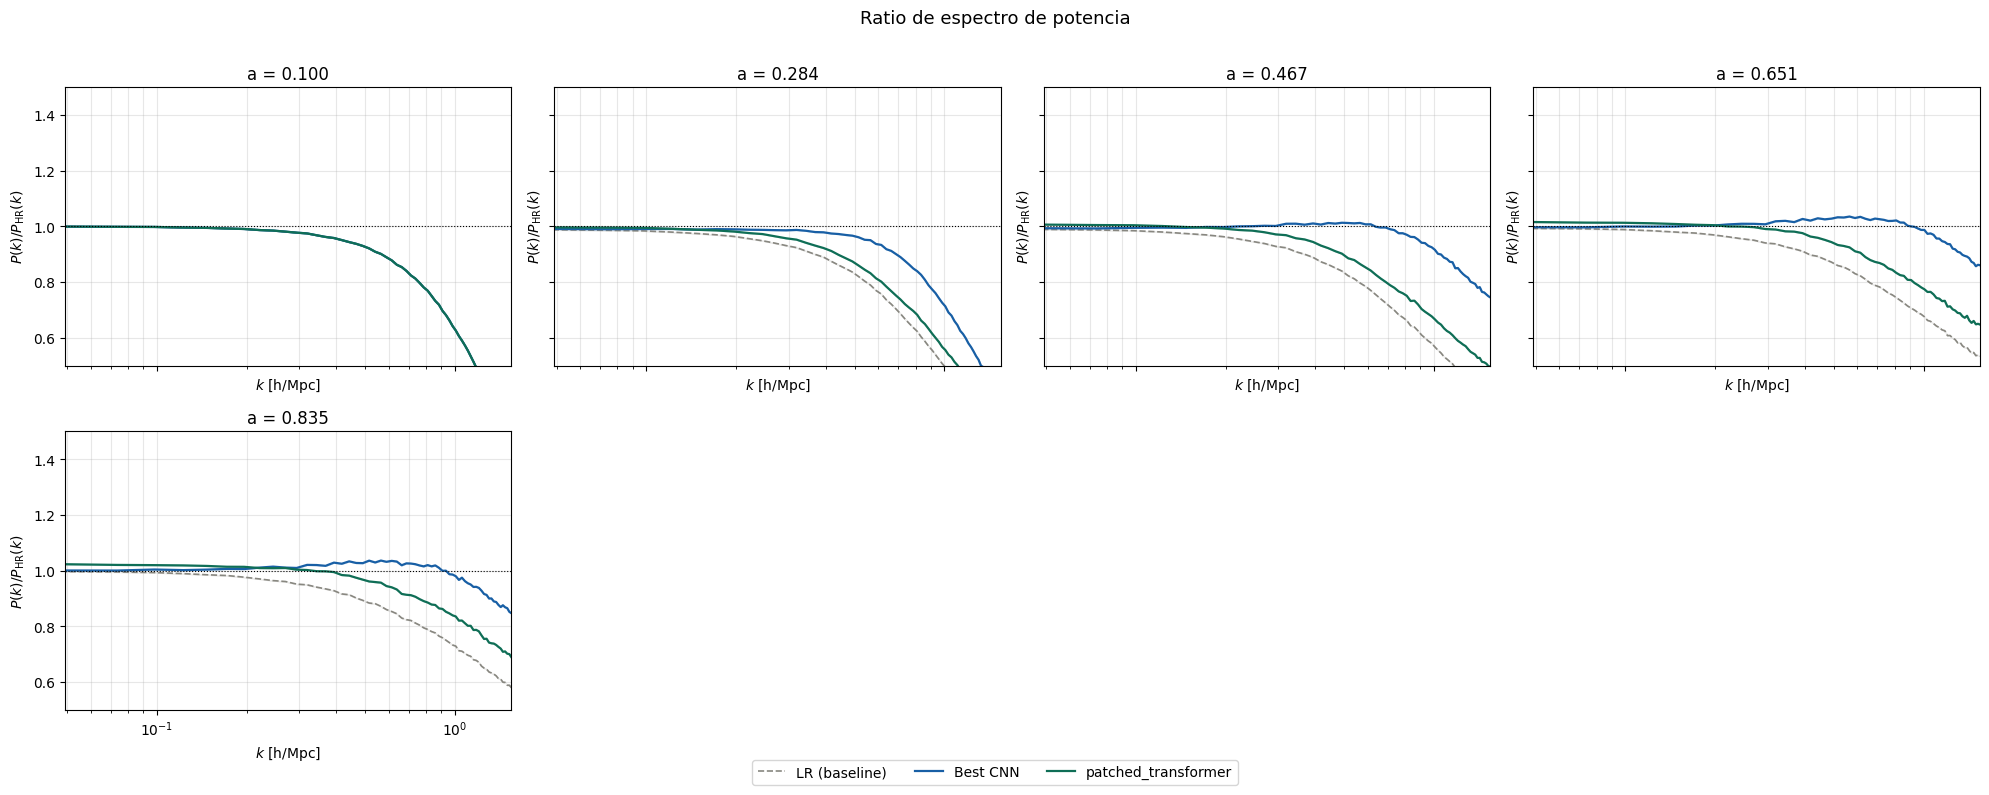

In [10]:
SNAPS_PLOT = SNAP_EVAL[::2]   # submuestra para no saturar la figura
ncols = min(4, len(SNAPS_PLOT))
nrows = (len(SNAPS_PLOT) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows),
                          sharey=True, sharex=True)
axes = np.array(axes).flatten()

for ax_i, snap in enumerate(SNAPS_PLOT):
    ax = axes[ax_i]
    for run_name in RUNS:
        d    = agg[run_name][snap]
        c    = color_map[run_name]
        ls, lw = ls_map[run_name]
        ax.semilogx(k_bins, d["pk_ratio_mean"],
                    color=c, ls=ls, lw=lw, label=run_name)
        ax.fill_between(k_bins,
                        d["pk_ratio_mean"] - d["pk_ratio_std"],
                        d["pk_ratio_mean"] + d["pk_ratio_std"],
                        color=c, alpha=0.15)
    ax.axhline(1.0, color="k", lw=0.8, ls=":")
    ax.set_xlim(k_bins[1], k_bins[-1])
    ax.set_ylim(0.5, 1.5)
    ax.set_xlabel(r"$k$ [h/Mpc]")
    ax.set_ylabel(r"$P(k)/P_{\rm HR}(k)$")
    ax.set_title(f"a = {d['a']:.3f}")
    ax.grid(True, which="both", alpha=0.3)

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(RUNS),
           bbox_to_anchor=(0.5, -0.02), fontsize=10)

# Ocultar ejes sobrantes
for ax in axes[len(SNAPS_PLOT):]:
    ax.set_visible(False)

fig.suptitle("Ratio de espectro de potencia", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 8 · r(k) — correlación cruzada

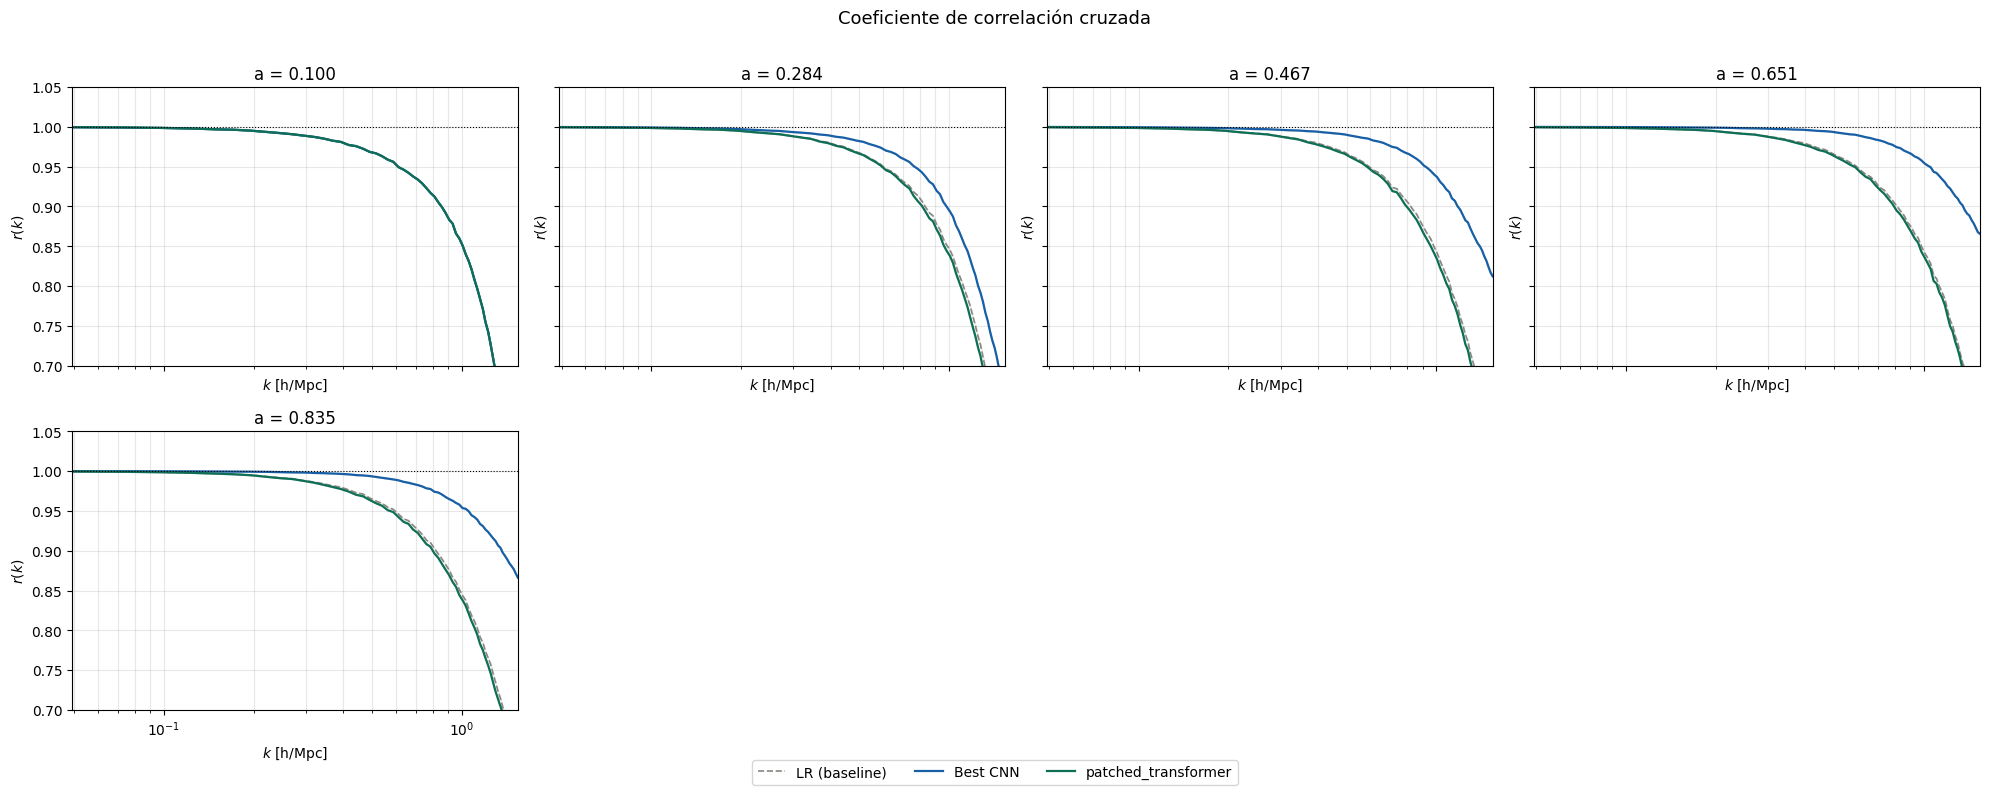

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows),
                          sharey=True, sharex=True)
axes = np.array(axes).flatten()

for ax_i, snap in enumerate(SNAPS_PLOT):
    ax = axes[ax_i]
    for run_name in RUNS:
        d    = agg[run_name][snap]
        c    = color_map[run_name]
        ls, lw = ls_map[run_name]
        ax.semilogx(k_bins, d["cross_corr_mean"],
                    color=c, ls=ls, lw=lw, label=run_name)
        ax.fill_between(k_bins,
                        d["cross_corr_mean"] - d["cross_corr_std"],
                        d["cross_corr_mean"] + d["cross_corr_std"],
                        color=c, alpha=0.15)
    ax.axhline(1.0, color="k", lw=0.8, ls=":")
    ax.set_xlim(k_bins[1], k_bins[-1])
    ax.set_ylim(0.7, 1.05)
    ax.set_xlabel(r"$k$ [h/Mpc]")
    ax.set_ylabel(r"$r(k)$")
    ax.set_title(f"a = {d['a']:.3f}")
    ax.grid(True, which="both", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(RUNS),
           bbox_to_anchor=(0.5, -0.02), fontsize=10)
for ax in axes[len(SNAPS_PLOT):]:
    ax.set_visible(False)

fig.suptitle("Coeficiente de correlación cruzada", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 9 · MSE de posiciones vs factor de escala

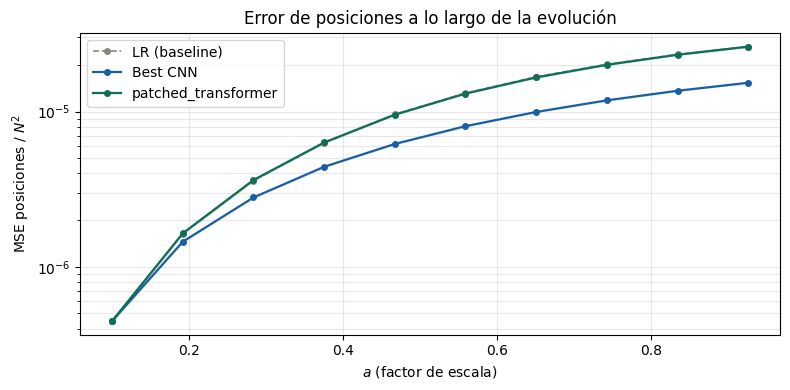

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

for run_name in RUNS:
    avals_plot = [agg[run_name][s]["a"]            for s in SNAP_EVAL]
    means      = [agg[run_name][s]["pos_mse_mean"] for s in SNAP_EVAL]
    stds       = [agg[run_name][s]["pos_mse_std"]  for s in SNAP_EVAL]
    c       = color_map[run_name]
    ls, lw  = ls_map[run_name]

    ax.semilogy(avals_plot, means, color=c, ls=ls, lw=lw, label=run_name, marker="o", ms=4)
    ax.fill_between(avals_plot,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    color=c, alpha=0.15)

ax.set_xlabel(r"$a$ (factor de escala)")
ax.set_ylabel(r"MSE posiciones / $N^2$")
ax.set_title("Error de posiciones a lo largo de la evolución")
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 10 · Slabs de densidad — última snapshot

In [13]:
# Parámetros del slab
SLAB_Z0_FRAC    = 0.5    # fracción de la caja donde cortar en z
SLAB_THICKNESS  = 16     # grosor en celdas (src_mesh)
SLAB_DST_MESH   = MESH_LR

SNAP_SLAB = SNAP_EVAL[-1]  # snapshot para los slabs

# Construir slabs por corrida (sólo primera sim de test)
SIM_SLAB  = TEST_SIM_IDS[0]
slabs     = {}

for run_name, run_entry in RUNS.items():
    if run_entry is None:
        run_info = None
    else:
        run_info = eu.load_run(run_entry)

    pos_lr, vel_lr, pos_hr, vel_hr, avals = eu.load_sim(
        DATA_DIR, SIM_SLAB, MESH_LR, MESH_HR, BOX_SIZE
    )

    if run_info is None:
        pos_pm, _ = eu.run_ode(
            pos_lr[0], vel_lr[0], avals,
            model=None, params=None,
            ode_type=None, mesh_lr=MESH_LR, cosmology=COSMOLOGY,
        )
    else:
        pos_pm, _ = eu.run_ode(
            pos_lr[0], vel_lr[0], avals,
            model=run_info["model"], params=run_info["params"],
            ode_type=run_info["ode_type"],
            mesh_lr=MESH_LR, cosmology=COSMOLOGY,
        )

    pos_snap = jax.device_get(pos_pm[SNAP_SLAB])
    slabs[run_name] = eu.slab_projection(
        pos_snap, src_mesh=MESH_LR, dst_mesh=SLAB_DST_MESH,
        slab_thickness=SLAB_THICKNESS, z0_frac=SLAB_Z0_FRAC,
    )
    del pos_pm, pos_lr, vel_lr, pos_hr, vel_hr, avals, pos_snap
    jax.clear_caches()

# ── Referencia HR ─────────────────────────────────────────────────────────────
pos_hr_ref = np.load(DATA_DIR / f"pos_m{MESH_HR}_s{SIM_SLAB}.npy").astype("float32")
pos_hr_ref = pos_hr_ref * (MESH_HR / BOX_SIZE)
slabs["HR (referencia)"] = eu.slab_projection(
    pos_hr_ref[SNAP_SLAB], src_mesh=MESH_HR, dst_mesh=SLAB_DST_MESH,
    slab_thickness=SLAB_THICKNESS, z0_frac=SLAB_Z0_FRAC,
)
del pos_hr_ref

/tmp/ipykernel_556307/2337885418.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


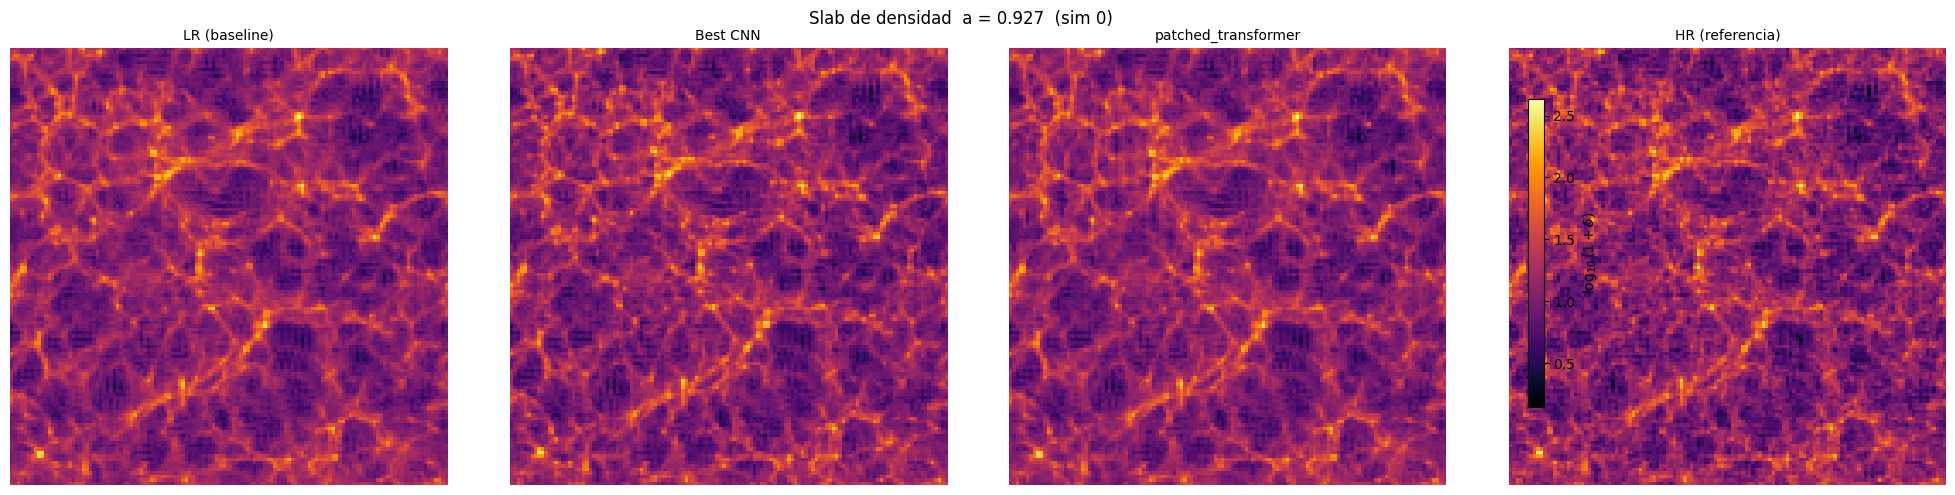

In [14]:
n_slabs = len(slabs)
fig, axes = plt.subplots(1, n_slabs, figsize=(5 * n_slabs, 5))
if n_slabs == 1:
    axes = [axes]

vmin = min(s.min() for s in slabs.values())
vmax = max(s.max() for s in slabs.values())

for ax, (name, slab) in zip(axes, slabs.items()):
    im = ax.imshow(slab, origin="lower", cmap="inferno",
                   vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=10)
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\log_{10}(1+\delta)$")
a_val = avals_cpu[SNAP_SLAB]
fig.suptitle(f"Slab de densidad  a = {a_val:.3f}  (sim {SIM_SLAB})", fontsize=12)
fig.tight_layout()
plt.show()

## 11 · Guardar resultados

In [ ]:
saved = eu.save_results(
    results=results,
    agg=agg,
    k_bins=k_bins,
    snap_indices=SNAP_EVAL,
    results_dir=RESULTS_DIR,
)
print("\nArchivos guardados:")
for label, path in saved.items():
    print(f"  {label}: {path}")